Install packages

In [1]:
!pip install rdkit einops -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Download & extract ChEMBL

In [2]:
# Download ChEMBL v36 SQLite database
# !wget -q --show-progress https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_36/chembl_36_sqlite.tar.gz

# # Extract it
# !tar -xzf chembl_36_sqlite.tar.gz

# # Verify
# !ls -lh chembl_36/chembl_36_sqlite/chembl_36.db

Query ADORA1

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('chembl_36/chembl_36_sqlite/chembl_36.db')

query = """
SELECT
    cs.canonical_smiles,
    act.pchembl_value,
    act.standard_type
FROM activities act
JOIN assays a ON act.assay_id = a.assay_id
JOIN target_dictionary td ON a.tid = td.tid
JOIN compound_structures cs ON act.molregno = cs.molregno
WHERE td.chembl_id = 'CHEMBL226'
  AND act.pchembl_value IS NOT NULL
  AND act.standard_relation = '='
"""

df = pd.read_sql_query(query, conn)
print(f"Raw records: {len(df)}")
df.head()

Raw records: 6603


,canonical_smiles,pchembl_value,standard_type
0,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)Nc4ccc(C(C)=O)cc4...,6.80,Ki
1,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)Nc4ccccc4C(C)=O)c...,6.47,Ki
2,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)O)cc3)[nH]c2n(CCC...,6.76,Ki
3,C=CCn1c(=O)c2nc(-c3ccc(OCC(=O)O)cc3)[nH]c2n(CC...,5.78,Ki
4,CC(C)CCn1cc2c(nc(NC(=O)Cc3ccccc3)n3nc(-c4ccco4...,6.70,Ki


Deduplicate & filter

In [4]:
# Deduplicate: keep median pChEMBL per compound
df_clean = df.groupby('canonical_smiles')['pchembl_value'].median().reset_index()

# Quality filter
df_clean = df_clean[df_clean['pchembl_value'] >= 5].reset_index(drop=True)
print(f"After cleaning: {len(df_clean)} compounds")

After cleaning: 4951 compounds


Histogram of binding affinities

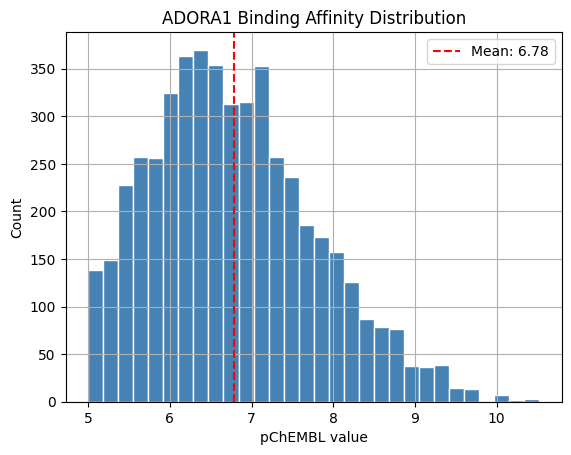

count    4951.000000
mean        6.784673
std         1.002177
min         5.000000
25%         6.030000
50%         6.670000
75%         7.420000
max        10.520000
Name: pchembl_value, dtype: float64


In [5]:
import matplotlib.pyplot as plt

df_clean['pchembl_value'].hist(bins=30, color='steelblue', edgecolor='white')
plt.xlabel('pChEMBL value')
plt.ylabel('Count')
plt.title('ADORA1 Binding Affinity Distribution')
plt.axvline(df_clean['pchembl_value'].mean(), color='red', linestyle='--',
            label=f"Mean: {df_clean['pchembl_value'].mean():.2f}")
plt.legend()
plt.show()
print(df_clean['pchembl_value'].describe())

Regression vs classification

In [6]:
threshold = 7.0
n_active = (df_clean['pchembl_value'] >= threshold).sum()
n_total = len(df_clean)
print(f"Active (>= {threshold}): {n_active} ({100*n_active/n_total:.1f}%)")
print(f"Inactive (< {threshold}): {n_total - n_active} ({100*(n_total-n_active)/n_total:.1f}%)")
print("Decision: regression (continuous pChEMBL, ~50/50 split confirms no strong threshold)")

Active (>= 7.0): 1941 (39.2%)
Inactive (< 7.0): 3010 (60.8%)
Decision: regression (continuous pChEMBL, ~50/50 split confirms no strong threshold)


Scaffold analysis

In [7]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return None

df_clean['scaffold'] = df_clean['canonical_smiles'].apply(get_scaffold)
print(f"Unique scaffolds: {df_clean['scaffold'].nunique()} out of {len(df_clean)} compounds")
print(f"Top 5 most common scaffolds:\n{df_clean['scaffold'].value_counts().head()}")

Unique scaffolds: 1993 out of 4951 compounds
Top 5 most common scaffolds:
scaffold
O=C(Nc1ccccc1)Nc1nc2n[nH]cc2c2nc(-c3ccco3)nn12    64
c1coc(-c2nc3c4c[nH]nc4ncn3n2)c1                   62
c1ncc2ncn(C3CCCO3)c2n1                            59
c1ccc(-c2cc(-c3ccccc3)ncn2)cc1                    56
c1ccc(CNc2ncnc3c2ncn3C2CCC3CC32)cc1               50
Name: count, dtype: int64


PCA

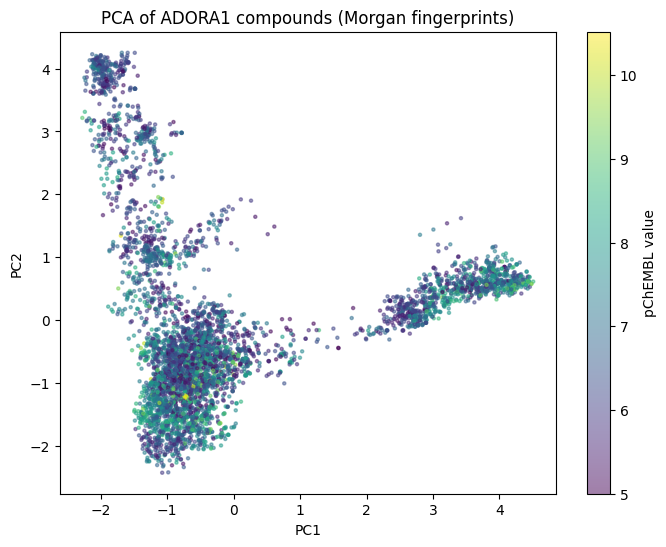

In [8]:
import numpy as np
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

mols = [Chem.MolFromSmiles(s) for s in df_clean['canonical_smiles']]
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048) for m in mols if m is not None]
X = np.array(fps)

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:,0], coords[:,1], c=df_clean['pchembl_value'],
                 cmap='viridis', alpha=0.5, s=5)
plt.colorbar(sc, label='pChEMBL value')
plt.title('PCA of ADORA1 compounds (Morgan fingerprints)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

MoLFormer-XL embeddings

In [9]:
import torch, types, math
import numpy as np
from typing import Optional, Tuple
from transformers import AutoTokenizer, AutoModel

# Load model (as before)
tokenizer = AutoTokenizer.from_pretrained(
    "ibm-research/MoLFormer-XL-both-10pct", trust_remote_code=True)
model = AutoModel.from_pretrained(
    "ibm-research/MoLFormer-XL-both-10pct",
    deterministic_eval=True, trust_remote_code=True, force_download=True)
model.eval()
model.get_head_mask = lambda head_mask, num_layers, is_attention_chunked=False: [None] * num_layers

# Patch linear attention with PR#7 correct formula
def _rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

def _apply_rotary(q, k, cos, sin, pos_ids):
    cos = cos[pos_ids].unsqueeze(1)
    sin = sin[pos_ids].unsqueeze(1)
    return (q * cos) + (_rotate_half(q) * sin), (k * cos) + (_rotate_half(k) * sin)

def _fixed_attn_fwd(self, hidden_states, attention_mask=None, position_ids=None,
                    head_mask=None, output_attentions=False):
    q = self.transpose_for_scores(self.query(hidden_states))
    k = self.transpose_for_scores(self.key(hidden_states))
    v = self.transpose_for_scores(self.value(hidden_states))

    L = k.shape[-2]
    cos, sin = self.rotary_embeddings(v, seq_len=L)
    q, k = _apply_rotary(q, k, cos, sin, position_ids)
    q, k = self.feature_map(q, k)

    if attention_mask is not None:
        # PR#7 fix: convert extended mask (0=valid, -inf=padding) back to 1/0
        mask = (attention_mask == 0).to(attention_mask.dtype)
        per_pos = mask[:, 0, -1]  # [B, S]
        k = k * per_pos[:, None, -L:, None]

    kv   = torch.matmul(k.transpose(-1, -2), v)
    norm = torch.matmul(q, k.sum(dim=-2).unsqueeze(-1)).clamp(min=self.eps)
    ctx  = torch.matmul(q, kv) / norm

    ctx = ctx.permute(0, 2, 1, 3).contiguous()
    ctx = ctx.view(ctx.size()[:-2] + (self.all_head_size,))
    return (ctx,)

for layer in model.encoder.layer:
    layer.attention.self.forward = types.MethodType(_fixed_attn_fwd, layer.attention.self)
print("Patched all 12 attention layers")

# Extract embeddings
def get_embedding(smiles):
    inputs = tokenizer(smiles, padding=True, return_tensors="pt")
    inputs = {k: v.to(next(model.parameters()).device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.pooler_output.squeeze().cpu().numpy()

print("Generating embeddings...")
embeddings = np.array([get_embedding(s) for s in df_clean['canonical_smiles']])
print(f"Embeddings shape: {embeddings.shape}")
print(f"NaN check: {np.isnan(embeddings).any()}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched all 12 attention layers
Generating embeddings...
Embeddings shape: (4951, 768)
NaN check: False


In [10]:
print(f"NaN check: {np.isnan(embeddings).any()}")

NaN check: False


In [11]:
nan_rows = np.isnan(embeddings).any(axis=1)
print(f"Molecules with NaN: {nan_rows.sum()} / {len(embeddings)}")

Molecules with NaN: 0 / 4951


In [12]:
# Check 1: are any weights bad?
bad_params = [(n, p.shape) for n, p in model.named_parameters()
              if torch.isnan(p).any() or torch.isinf(p).any()]
print(f"Bad parameters: {bad_params if bad_params else 'None'}")

# Check 2: magnitude at each layer for a real molecule
smiles = df_clean['canonical_smiles'].iloc[0]
inputs = tokenizer(smiles, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)
for i, h in enumerate(outputs.hidden_states):
    if torch.isnan(h).any():
        print(f"Layer {i}: NaN")
    else:
        print(f"Layer {i}: max={h.abs().max().item():.2f}, mean={h.abs().mean().item():.4f}")

Bad parameters: None
Layer 0: max=3.75, mean=0.7901
Layer 1: max=10.81, mean=0.6875
Layer 2: max=11.76, mean=0.6544
Layer 3: max=13.89, mean=0.6336
Layer 4: max=13.63, mean=0.6277
Layer 5: max=13.20, mean=0.6202
Layer 6: max=12.05, mean=0.6249
Layer 7: max=12.98, mean=0.6402
Layer 8: max=14.28, mean=0.6261
Layer 9: max=14.71, mean=0.6423
Layer 10: max=14.75, mean=0.6285
Layer 11: max=10.66, mean=0.5358
Layer 12: max=13.32, mean=0.7255


MoLFormer-XL + MLP (Random Split — Pilot)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, df_clean['pchembl_value'].values,
    test_size=0.2, random_state=42
)

mlp = MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=200, random_state=42, verbose=True)
mlp.fit(X_train, y_train)

y_pred_random = mlp.predict(X_test)
y_test_random = y_test
r_random, _ = pearsonr(y_test_random, y_pred_random)
rmse_random = np.sqrt(mean_squared_error(y_test_random, y_pred_random))

print(f"\nRandom split | Pearson R: {r_random:.3f} | RMSE: {rmse_random:.3f}")

Iteration 1, loss = 2.42330631
Iteration 2, loss = 0.53439312
Iteration 3, loss = 0.42320815
Iteration 4, loss = 0.38500507
Iteration 5, loss = 0.36290242
Iteration 6, loss = 0.34389216
Iteration 7, loss = 0.32400156
Iteration 8, loss = 0.30723654
Iteration 9, loss = 0.29085190
Iteration 10, loss = 0.27731091
Iteration 11, loss = 0.26059452
Iteration 12, loss = 0.25122946
Iteration 13, loss = 0.23341988
Iteration 14, loss = 0.22967849
Iteration 15, loss = 0.21486267
Iteration 16, loss = 0.20250842
Iteration 17, loss = 0.19550247
Iteration 18, loss = 0.19680346
Iteration 19, loss = 0.18314613
Iteration 20, loss = 0.17300594
Iteration 21, loss = 0.16686051
Iteration 22, loss = 0.16360190
Iteration 23, loss = 0.15339929
Iteration 24, loss = 0.15342871
Iteration 25, loss = 0.14726083
Iteration 26, loss = 0.13906238
Iteration 27, loss = 0.13957644
Iteration 28, loss = 0.12941416
Iteration 29, loss = 0.12491726
Iteration 30, loss = 0.11497085
Iteration 31, loss = 0.11782379
Iteration 32, los

Scaffold-Based Split (RDKit Butina, Tanimoto 0.4)

In [14]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.ML.Cluster import Butina
import numpy as np

# Compute Morgan fingerprints
fps = []
for smi in df_clean['canonical_smiles']:
    mol = Chem.MolFromSmiles(smi)
    fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))

# Compute Tanimoto distance matrix (upper triangle)
nfps = len(fps)
dists = []
for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1 - s for s in sims])

# Butina clustering (distance cutoff 0.6 = Tanimoto similarity 0.4)
clusters = Butina.ClusterData(dists, nfps, 0.6, isDistData=True)

# Assign cluster IDs
cluster_ids = np.zeros(nfps, dtype=int)
for cid, cluster in enumerate(clusters):
    for idx in cluster:
        cluster_ids[idx] = cid

# 80/20 split at cluster level (no scaffold leakage)
unique_clusters = np.unique(cluster_ids)
np.random.seed(42)
np.random.shuffle(unique_clusters)
n_test = int(0.2 * len(unique_clusters))
test_clusters = set(unique_clusters[:n_test])

train_idx = np.array([i for i in range(nfps) if cluster_ids[i] not in test_clusters])
test_idx  = np.array([i for i in range(nfps) if cluster_ids[i] in test_clusters])

print(f"Clusters: {len(unique_clusters)}")
print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

Clusters: 376
Train: 3462 | Test: 1489


MoLFormer-XL + MLP (Scaffold Split)

In [15]:
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr
import numpy as np

X = embeddings
y = df_clean['pchembl_value'].values
X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

seeds = [42, 7, 13, 99, 21]
lrs = [0.001, 0.0005, 0.0001]

for lr in lrs:
    rs = []
    for seed in seeds:
        model = MLPRegressor(hidden_layer_sizes=(512, 256, 128), max_iter=1000,
                             early_stopping=True, validation_fraction=0.1,
                             activation='tanh', alpha=0.001,
                             learning_rate_init=lr, random_state=seed)
        model.fit(X_train, y_train)
        r, _ = pearsonr(model.predict(X_test), y_test)
        rs.append(r)
    print(f"lr={lr}  Mean R={np.mean(rs):.4f}  Std={np.std(rs):.4f}")

y_test_scaffold = y_test
y_pred_scaffold = model.predict(X_test)
r_scaffold = np.mean(rs)
rmse_scaffold = np.sqrt(np.mean((y_test_scaffold - y_pred_scaffold) ** 2))

lr=0.001  Mean R=0.4007  Std=0.0181
lr=0.0005  Mean R=0.3612  Std=0.0193
lr=0.0001  Mean R=0.3436  Std=0.0238


Scatterplot of predicted vs ground truth pChEMBL values

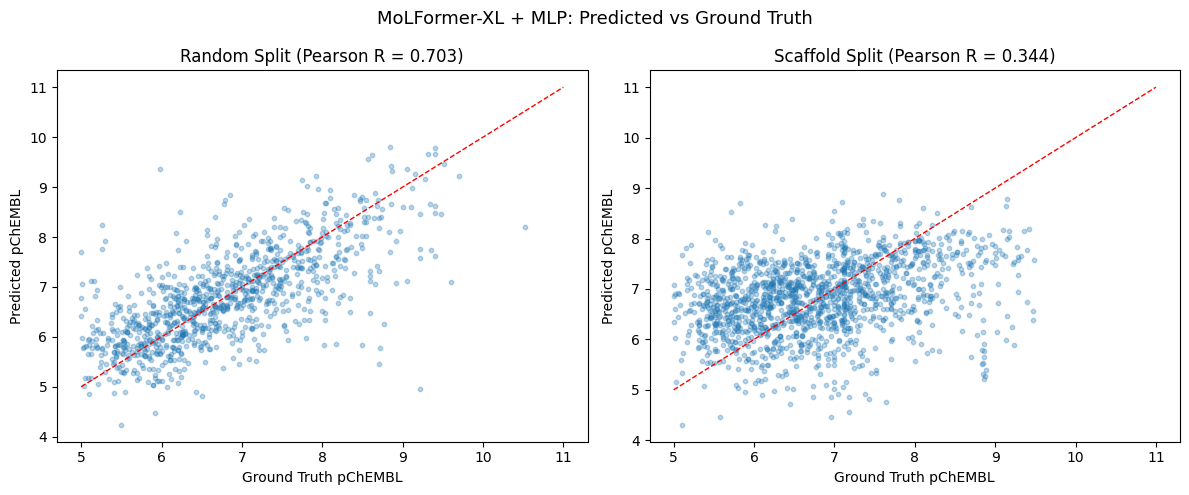

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_random, y_pred_random, alpha=0.3, s=10)
axes[0].plot([5, 11], [5, 11], 'r--', linewidth=1)
axes[0].set_xlabel('Ground Truth pChEMBL')
axes[0].set_ylabel('Predicted pChEMBL')
axes[0].set_title(f'Random Split (Pearson R = {r_random:.3f})')

axes[1].scatter(y_test_scaffold, y_pred_scaffold, alpha=0.3, s=10)
axes[1].plot([5, 11], [5, 11], 'r--', linewidth=1)
axes[1].set_xlabel('Ground Truth pChEMBL')
axes[1].set_ylabel('Predicted pChEMBL')
axes[1].set_title(f'Scaffold Split (Pearson R = {r_scaffold:.3f})')

plt.suptitle('MoLFormer-XL + MLP: Predicted vs Ground Truth', fontsize=13)
plt.tight_layout()
plt.show()

Config log

In [17]:
import pandas as pd
import os

config = {
    'model': 'ibm/MoLFormer-XL-both-10pct',
    'embedding_dim': embeddings.shape[1],
    'regressor': 'MLP (256, 128)',
    'max_iter': 200,
    'split_random_r': r_random,
    'split_random_rmse': rmse_random,
    'split_scaffold_r': r_scaffold,
    'split_scaffold_rmse': rmse_scaffold,
    'n_compounds': len(df_clean),
    'target': 'ADORA1',
    'notes': 'MoLFormer-XL (45M), mean pooling, inference-only, no protein embedding'
}

log_path = 'config_log.csv'
df_log = pd.DataFrame([config])
if os.path.exists(log_path):
    df_log = pd.concat([pd.read_csv(log_path), df_log], ignore_index=True)
df_log.to_csv(log_path, index=False)
print(df_log)

                         model  embedding_dim       regressor  max_iter  \
0  ibm/MoLFormer-XL-both-10pct            768  MLP (256, 128)       200   

   split_random_r  split_random_rmse  split_scaffold_r  split_scaffold_rmse  \
0        0.703334           0.745692          0.343553             1.014585   

   n_compounds  target                                              notes  
0         4951  ADORA1  MoLFormer-XL (45M), mean pooling, inference-on...  
